In [1]:
import pandas as pd
import re
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score,
    precision_score, recall_score, accuracy_score
)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from google.colab import drive

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Đã cố định SEED = {SEED} cho toàn bộ pipeline.")

Đã cố định SEED = 42 cho toàn bộ pipeline.


In [3]:
# 0. HẰNG SỐ TOÀN CỤC

ASPECTS = ['Vị trí', 'Dịch vụ', 'Giá cả', 'Cơ sở vật chất', 'Vệ sinh']
SENTIMENT_MAP = {'Tiêu cực': 0, 'Trung lập': 1, 'Tích cực': 2}
NONE_VALUE    = 3
NUM_CLASSES   = 4   # 0=Tiêu cực, 1=Trung lập, 2=Tích cực, 3=None
TARGET_NAMES  = ['Tiêu cực', 'Trung lập', 'Tích cực', 'None']
MODEL_NAME    = "vinai/phobert-base-v2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang chạy trên: {device}")

Đang chạy trên: cuda


In [4]:
# 1. ĐỌC DỮ LIỆU
# =============================================================================
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/NLP/ĐỒ ÁN CUỐI KỲ_NLP_NHOM6/Source code/Data ABSA.csv'
df = pd.read_csv(file_path, encoding='utf-8')
print(f"Đã đọc file thành công! Tổng số dòng gốc: {len(df)}")

Mounted at /content/drive
Đã đọc file thành công! Tổng số dòng gốc: 6357


In [5]:
# 2. EDA
# =============================================================================
sentiments = ['Tích cực', 'Trung lập', 'Tiêu cực']
stats_dict = {a: {s: 0 for s in sentiments} for a in ASPECTS}

for label_str in df['Label'].astype(str):
    # [FIX #2] Dùng split('#') nhất quán — không thêm bước split(';') thừa
    found = re.findall(r'\{(.*?)\}', label_str)
    for item in found:
        parts = item.split('#')
        if len(parts) == 2:
            a_part = parts[0].strip()
            s_part = parts[1].strip()
            if a_part in stats_dict and s_part in sentiments:
                stats_dict[a_part][s_part] += 1

df_report = pd.DataFrame.from_dict(stats_dict, orient='index').reset_index()
df_report.columns = ['Khía cạnh', 'Tích cực', 'Trung lập', 'Tiêu cực']
df_report['Tổng cộng'] = df_report[['Tích cực', 'Trung lập', 'Tiêu cực']].sum(axis=1)

print("--- BẢNG THỐNG KÊ KẾT QUẢ GÁN NHÃN ---")
print(df_report.to_markdown(index=False))

# --- Biểu đồ phân bổ số khía cạnh / câu ---
def count_aspects(label_str):
    if pd.isna(label_str) or label_str == "":
        return 0
    return len(re.findall(r'\{(.*?)\}', str(label_str)))

df['Aspect_Count'] = df['Label'].apply(count_aspects)
df_plot_1 = df[df['Aspect_Count'] > 0].copy()
dist_data = df_plot_1['Aspect_Count'].value_counts().sort_index().reset_index()
dist_data.columns = ['So_Luong', 'Counts']
dist_data['Labels'] = dist_data['So_Luong'].apply(lambda x: f"{x} Khía cạnh")

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=dist_data, x='Labels', y='Counts',
                 palette='Blues_d', hue='Labels', legend=False)
plt.title('PHÂN BỔ MẬT ĐỘ THÔNG TIN TRÊN MỖI CÂU ĐÁNH GIÁ',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mức độ chi tiết của Review', fontsize=12)
plt.ylabel('Số lượng câu (Reviews)', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Stacked bar ---
if 'Khía cạnh' in df_report.columns:
    df_report = df_report.set_index('Khía cạnh')

ax = df_report[['Tích cực', 'Trung lập', 'Tiêu cực']].plot(
    kind='barh', stacked=True, figsize=(12, 7),
    color=['#2ecc71', '#f1c40f', '#e74c3c'],
    edgecolor='black', width=0.7)
plt.title('PHÂN PHỐI CẢM XÚC TRÊN 5 KHÍA CẠNH',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Số lượng nhãn (Lượt xuất hiện)', fontsize=12)
plt.ylabel('Khía cạnh', fontsize=12)
plt.legend(title='Cảm xúc', bbox_to_anchor=(1.05, 1), loc='upper left')
for p in ax.patches:
    width = p.get_width()
    if width > 5:
        ax.text(p.get_x() + width/2, p.get_y() + p.get_height()/2,
                f'{int(width)}', ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Pie chart ---
aspect_counts = {a: 0 for a in ASPECTS}
for label_str in df['Label'].astype(str):
    found = re.findall(r'\{(.*?)\}', label_str)
    for item in found:
        if '#' in item:
            asp = item.split('#')[0].strip()
            if asp in aspect_counts:
                aspect_counts[asp] += 1

s_aspects = pd.Series(aspect_counts).sort_values(ascending=False)
colors = ['#5dade2', '#58d68d', '#f5b041', '#ec7063', '#af7ac5']
plt.figure(figsize=(10, 8), dpi=100)
plt.pie(s_aspects, labels=s_aspects.index, autopct='%1.1f%%',
        startangle=90, colors=colors, pctdistance=0.85,
        explode=[0.02]*len(s_aspects),
        textprops={'fontsize': 11, 'fontweight': 'bold'})
plt.title('PHÂN BỔ TỶ TRỌNG 5 KHÍA CẠNH ĐÁNH GIÁ',
          fontsize=15, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

# --- Co-occurrence heatmap ---
binary_data = []
for label_str in df['Label'].astype(str):
    row_presence = {a: 0 for a in ASPECTS}
    found = re.findall(r'\{(.*?)\}', label_str)
    for item in found:
        if '#' in item:
            asp = item.split('#')[0].strip()
            if asp in row_presence:
                row_presence[asp] = 1
    binary_data.append(row_presence)

df_binary = pd.DataFrame(binary_data)
co_occurrence_matrix = df_binary.T.dot(df_binary)
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, annot=True, cmap='YlGnBu',
            fmt="d", linewidths=0.5)
plt.title('MA TRẬN SỐ LƯỢNG XUẤT HIỆN ĐỒNG THỜI GIỮA CÁC KHÍA CẠNH',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# --- Review length histogram ---
df['Review_Length'] = df['Review_Final'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(12, 6))
sns.histplot(df['Review_Length'], bins=50, kde=True, color='skyblue', edgecolor='black')
mean_len   = df['Review_Length'].mean()
median_len = df['Review_Length'].median()
plt.axvline(mean_len,   color='red',   linestyle='--', label=f'Trung bình: {mean_len:.1f}')
plt.axvline(median_len, color='green', linestyle='-',  label=f'Trung vị: {median_len:.1f}')
plt.title('PHÂN PHỐI ĐỘ DÀI CÂU REVIEW (SỐ LƯỢNG TỪ)',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Độ dài câu (Số lượng từ)', fontsize=12)
plt.ylabel('Số lượng câu', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()
print(f"Câu ngắn nhất : {df['Review_Length'].min()} từ")
print(f"Câu dài nhất  : {df['Review_Length'].max()} từ")
print(f"Độ dài trung bình: {mean_len:.2f} từ")
print(f"Số câu ≤ 100 từ: {len(df[df['Review_Length'] <= 100])}")

--- BẢNG THỐNG KÊ KẾT QUẢ GÁN NHÃN ---
| Khía cạnh      |   Tích cực |   Trung lập |   Tiêu cực |   Tổng cộng |
|:---------------|-----------:|------------:|-----------:|------------:|
| Vị trí         |       3119 |         694 |        111 |        3924 |
| Dịch vụ        |       3414 |           0 |        821 |        4235 |
| Giá cả         |       1113 |         488 |        319 |        1920 |
| Cơ sở vật chất |       2351 |         752 |       1295 |        4398 |
| Vệ sinh        |       2164 |        1365 |        373 |        3902 |
Câu ngắn nhất : 1 từ
Câu dài nhất  : 375 từ
Độ dài trung bình: 23.57 từ
Số câu ≤ 100 từ: 6164


In [6]:
# 3. TIỀN XỬ LÝ — TẠO df_encoded (dùng chung cho cả 3 mô hình)
# =============================================================================
def extract_labels(label_str):
    """
    [FIX #2] Hàm parse label duy nhất, nhất quán cho toàn notebook.
    Format: {Aspect#Sentiment} — chỉ dùng split('#'), không split(';').
    """
    res = {asp: NONE_VALUE for asp in ASPECTS}
    matches = re.findall(r'\{(.*?)\}', str(label_str))
    for m in matches:
        if '#' in m:
            parts = m.split('#')
            asp  = parts[0].strip()
            sent = parts[1].strip()
            if asp in res and sent in SENTIMENT_MAP:
                res[asp] = SENTIMENT_MAP[sent]
    return pd.Series(res)

df_encoded   = df['Label'].apply(extract_labels)
df_base      = pd.concat([df['Review_Final'], df_encoded], axis=1).reset_index(drop=True)

print("Dữ liệu sau khi encode (5 dòng đầu):")
print(df_base.head())

Dữ liệu sau khi encode (5 dòng đầu):
                                        Review_Final  Vị trí  Dịch vụ  Giá cả  \
0  cách phố đi nguyễn huệ 200 m vincom đồng_khởi ...       2        3       3   
1  chuyến đi tuần_trăng_mật không_thể khen khách_...       2        2       2   
2  khách_sạn không_khí boutique dễ_thương vị_trí ...       2        3       3   
3  chúng_tôi kỳ nghỉ dễ_chịu the myst vị_trí tuyệ...       2        2       1   
4  vợ_chồng phòng chúng_tôi tình_cờ chính_xác phò...       1        0       0   

   Cơ sở vật chất  Vệ sinh  
0               3        2  
1               2        1  
2               2        3  
3               2        1  
4               0        0  


In [8]:
# 4. DATASET CLASS
# =============================================================================
class ABSADataset(Dataset):
    """Dataset class dùng chung cho cả PhoBERT thuần và Hybrid."""
    def __init__(self, df, tokenizer, max_len=128):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row  = self.df.iloc[index]
        text = str(row['Review_Final'])

        encoding = self.tokenizer(
            text,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
        )

        labels = torch.tensor(
            row[ASPECTS].values.astype(int), dtype=torch.long
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels,
            "idx": torch.tensor(index, dtype=torch.long)
        }

In [19]:
# 5. MÔ HÌNH PHOBERT THUẦN
# =============================================================================
class PhoBERT_ABSA(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert        = AutoModel.from_pretrained(MODEL_NAME)
        self.drop        = nn.Dropout(p=0.5)
        self.classifiers = nn.ModuleList(
            [nn.Linear(768, NUM_CLASSES) for _ in range(len(ASPECTS))]
        )

    def forward(self, input_ids, attention_mask):
        outputs    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        x          = self.drop(cls_output)
        return [cl(x) for cl in self.classifiers]


def train_phobert(df_base, tokenizer):
    """
    [FIX #1] Split trước khi làm bất cứ điều gì → không data leakage.
    """
    train_df, val_df = train_test_split(df_base, test_size=0.2, random_state=42)

    train_loader = DataLoader(ABSADataset(train_df, tokenizer),
                              batch_size=16, shuffle=True)
    val_loader   = DataLoader(ABSADataset(val_df, tokenizer),
                              batch_size=16)

    model = PhoBERT_ABSA().to(device)

    weights = torch.tensor([2.5, 2.0, 1.0, 0.8]).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)

    optimizer = AdamW([
        {'params': model.bert.parameters(),        'lr': 5e-6},
        {'params': model.classifiers.parameters(), 'lr': 3e-5},
    ], weight_decay=0.02)

    EPOCHS      = 20
    patience    = 3
    # [FIX #5] total_steps tính trên train_loader vừa tạo
    total_steps = len(train_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )

    best_val_loss   = float('inf')
    early_stop_count = 0
    history          = {'train_loss': [], 'val_loss': []}
    y_targets = y_preds = None

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        # --- TRAIN ---
        model.train()
        train_losses = []
        for d in tqdm(train_loader, desc="Training"):
            ids     = d['input_ids'].to(device)
            mask    = d['attention_mask'].to(device)
            targets = d['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(ids, mask)
            loss    = sum(loss_fn(outputs[i], targets[:, i]) for i in range(len(ASPECTS)))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            train_losses.append(loss.item())

        # --- VALIDATION ---
        model.eval()
        val_losses   = []
        all_targets  = []
        all_preds    = []
        all_idx=[]
        with torch.no_grad():
            for d in val_loader:
                ids     = d['input_ids'].to(device)
                mask    = d['attention_mask'].to(device)
                targets = d['labels'].to(device)
                idxs = d['idx']

                outputs = model(ids, mask)
                v_loss  = sum(loss_fn(outputs[i], targets[:, i]) for i in range(len(ASPECTS)))
                val_losses.append(v_loss.item())

                all_targets.extend(targets.cpu().numpy())
                all_preds.extend(
                    torch.stack([torch.argmax(o, dim=1) for o in outputs], dim=1).cpu().numpy()
                )
                all_idx.extend(idxs.cpu().numpy())

        avg_train = np.mean(train_losses)
        avg_val   = np.mean(val_losses)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        print(f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            torch.save(model.state_dict(), 'best_model_phobert.bin')
            y_targets        = np.array(all_targets)
            y_preds          = np.array(all_preds)
            y_indices = np.array(all_idx)
            early_stop_count = 0
            print("Mô hình cải thiện! Đã lưu.")
        else:
            early_stop_count += 1
            if early_stop_count >= patience:
                print("Early stopping triggered.")
                break

    return model, y_targets, y_preds, y_indices, val_df

In [20]:
# 6. MÔ HÌNH HYBRID PHOBERT + BiLSTM
# =============================================================================
class PhoBERT_BiLSTM_ABSA(nn.Module):
    def __init__(self, hidden_size=256, dropout_prob=0.5):
        super().__init__()
        self.bert        = AutoModel.from_pretrained(MODEL_NAME)
        self.lstm        = nn.LSTM(768, hidden_size, batch_first=True, bidirectional=True)
        self.drop        = nn.Dropout(p=dropout_prob)
        self.classifiers = nn.ModuleList(
            [nn.Linear(hidden_size * 2, NUM_CLASSES) for _ in range(len(ASPECTS))]
        )

    def forward(self, input_ids, attention_mask):
        outputs  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        lstm_out, (h_n, _) = self.lstm(outputs.last_hidden_state)
        # Ghép hidden state chiều tiến và chiều lùi
        out = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
        x   = self.drop(out)
        return [cl(x) for cl in self.classifiers]


def train_hybrid(df_base, tokenizer):
    """
    [FIX #1] Split trước — không data leakage.
    [FIX #5] Scheduler tính lại total_steps riêng cho model này.
    """
    train_df, val_df = train_test_split(df_base, test_size=0.2, random_state=42)

    train_loader = DataLoader(ABSADataset(train_df, tokenizer),
                              batch_size=16, shuffle=True)
    val_loader   = DataLoader(ABSADataset(val_df, tokenizer),
                              batch_size=16)

    model = PhoBERT_BiLSTM_ABSA().to(device)

    weights = torch.tensor([2.5, 2.0, 1.0, 0.8]).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)

    optimizer = AdamW([
        {'params': model.bert.parameters(),        'lr': 5e-6},
        {'params': model.lstm.parameters(),        'lr': 3e-5},
        {'params': model.classifiers.parameters(), 'lr': 5e-5},
    ], weight_decay=0.02)

    EPOCHS      = 20
    patience    = 3
    # [FIX #5] total_steps riêng cho hybrid
    total_steps = len(train_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )

    best_val_loss    = float('inf')
    early_stop_count = 0
    history          = {'train_loss': [], 'val_loss': []}
    final_y_targets  = final_y_preds = None

    print(f"--- BẮT ĐẦU HUẤN LUYỆN HYBRID MODEL (GPU: {device}) ---")

    for epoch in range(EPOCHS):
        # TRAIN
        model.train()
        train_losses = []
        for d in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            ids     = d['input_ids'].to(device)
            mask    = d['attention_mask'].to(device)
            targets = d['labels'].to(device)
            optimizer.zero_grad()
            outputs = model(ids, mask)
            loss    = sum(loss_fn(outputs[i], targets[:, i]) for i in range(len(ASPECTS)))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            train_losses.append(loss.item())

        # VALIDATION
        model.eval()
        val_losses  = []
        all_targets = []
        all_preds   = []
        all_idx     = []
        with torch.no_grad():
            for d in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
                ids     = d['input_ids'].to(device)
                mask    = d['attention_mask'].to(device)
                targets = d['labels'].to(device)
                idxs = d['idx']

                outputs = model(ids, mask)
                v_loss  = sum(loss_fn(outputs[i], targets[:, i]) for i in range(len(ASPECTS)))
                val_losses.append(v_loss.item())

                all_targets.extend(targets.cpu().numpy())
                all_preds.extend(
                    torch.stack([torch.argmax(o, dim=1) for o in outputs], dim=1).cpu().numpy()
                )
                all_idx.extend(idxs.cpu().numpy())

        avg_train = np.mean(train_losses)
        avg_val   = np.mean(val_losses)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        print(f"Epoch {epoch+1}: Train {avg_train:.4f} | Val {avg_val:.4f}")

        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            torch.save(model.state_dict(), 'hybrid_best_model.bin')
            final_y_targets  = np.array(all_targets)
            final_y_preds    = np.array(all_preds)
            final_y_indices = np.array(all_idx)
            early_stop_count = 0
            print("=> Model improved & saved!")
        else:
            early_stop_count += 1
            print(f"=> EarlyStopping counter: {early_stop_count}/{patience}")
            if early_stop_count >= patience:
                print("!!! Early stopping triggered.")
                break

    return model, final_y_targets, final_y_preds, final_y_indices, val_df

In [21]:
# 7. DATA AUGMENTATION
# =============================================================================
def augment_text(text, n_aug=2):
    words = text.split()
    augmented = []
    for _ in range(n_aug):
        new_words = words.copy()
        if len(new_words) > 5:
            idx = random.randint(0, len(new_words) - 1)
            del new_words[idx]
        if len(new_words) > 5:
            i, j = random.sample(range(len(new_words)), 2)
            new_words[i], new_words[j] = new_words[j], new_words[i]
        augmented.append(" ".join(new_words))
    return augmented


def augment_train_only(train_df):
    """
    [FIX #1] Chỉ augment trên train_df — KHÔNG chạm vào val_df.
    Bước này phải gọi SAU khi đã split.
    """
    df_neg_neu = train_df[
        (train_df[ASPECTS] == 0).any(axis=1) |
        (train_df[ASPECTS] == 1).any(axis=1)
    ]

    augmented_rows = []
    for _, row in df_neg_neu.iterrows():
        for aug_text in augment_text(str(row['Review_Final']), n_aug=2):
            new_row = row.copy()
            new_row['Review_Final'] = aug_text
            augmented_rows.append(new_row)

    df_aug    = pd.DataFrame(augmented_rows)
    df_result = pd.concat([train_df, df_aug]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"✅ Augmented train: {len(train_df)} → {len(df_result)} mẫu")
    return df_result


def train_hybrid_augmented(df_base, tokenizer):
    """
    [FIX #1] Split → augment train → train model.
    """
    # Bước 1: Split sạch
    train_df, val_df = train_test_split(df_base, test_size=0.2, random_state=42)

    # Bước 2: Chỉ augment TRAIN
    train_df_aug = augment_train_only(train_df)

    print("\n📊 BEFORE AUGMENT (train):")
    print(train_df[ASPECTS].apply(pd.Series.value_counts))
    print("\n📈 AFTER AUGMENT (train):")
    print(train_df_aug[ASPECTS].apply(pd.Series.value_counts))

    train_loader = DataLoader(ABSADataset(train_df_aug, tokenizer, max_len=128),
                              batch_size=32, shuffle=True)
    val_loader   = DataLoader(ABSADataset(val_df, tokenizer, max_len=128),
                              batch_size=32)

    model     = PhoBERT_BiLSTM_ABSA(dropout_prob=0.3).to(device)
    criterion = nn.CrossEntropyLoss()   # không weighted — dữ liệu đã cân bằng qua augment
    optimizer = AdamW(model.parameters(), lr=2e-5)

    EPOCHS      = 10
    patience    = 3
    # [FIX #5] total_steps riêng cho phiên bản augmented
    total_steps = len(train_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )

    history          = {'train_loss': [], 'val_loss': []}
    best_val_loss    = float('inf')
    early_stop_count = 0
    final_y_targets = final_y_preds = final_y_indices = None

    print(f"\n--- BẮT ĐẦU HUẤN LUYỆN HYBRID + AUGMENT (GPU: {device}) ---")

    for epoch in range(EPOCHS):
        # TRAIN
        model.train()
        total_train_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/Train"):
            optimizer.zero_grad()
            ids     = batch['input_ids'].to(device)
            mask    = batch['attention_mask'].to(device)
            outputs = model(ids, mask)
            loss    = sum(criterion(outputs[i], batch['labels'][:, i].to(device))
                          for i in range(len(ASPECTS)))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_train_loss += loss.item()

        # VAL
        model.eval()
        total_val_loss  = 0
        all_targets_ep  = []
        all_preds_ep    = []
        all_idx_ep = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/Val"):
                ids     = batch['input_ids'].to(device)
                mask    = batch['attention_mask'].to(device)
                outputs = model(ids, mask)
                idxs = batch['idx']
                v_loss  = sum(criterion(outputs[i], batch['labels'][:, i].to(device))
                              for i in range(len(ASPECTS)))
                total_val_loss += v_loss.item()

                batch_targets = np.array(
                    [batch['labels'][:, i].cpu().numpy() for i in range(len(ASPECTS))]
                ).T
                batch_preds = np.array(
                    [torch.argmax(outputs[i], dim=1).cpu().numpy() for i in range(len(ASPECTS))]
                ).T
                all_targets_ep.extend(batch_targets)
                all_preds_ep.extend(batch_preds)
                all_idx_ep.extend(idxs.cpu().numpy())

        avg_train = total_train_loss / len(train_loader)
        avg_val   = total_val_loss   / len(val_loader)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        print(f"Epoch {epoch+1}: Train {avg_train:.4f} | Val {avg_val:.4f}")

        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            torch.save(model.state_dict(), 'hybrid_aug_best_model.bin')
            final_y_targets  = np.array(all_targets_ep)
            final_y_preds    = np.array(all_preds_ep)
            final_y_indices = np.array(all_idx_ep)

            early_stop_count = 0
            print("=> Model improved & saved!")
        else:
            early_stop_count += 1
            print(f"=> EarlyStopping counter: {early_stop_count}/{patience}")
            if early_stop_count >= patience:
                print("!!! Early stopping triggered.")
                break

    return model, final_y_targets, final_y_preds, final_y_indices, val_df

In [22]:
# 8. HÀM EVALUATION (dùng chung cho cả 3 mô hình)
# =============================================================================
def report_per_aspect_sentiment(y_true, y_pred, model_name="Model"):
    """
    [FIX #3] Dùng ASPECTS toàn cục — thứ tự luôn khớp với index.
    [FIX #4] Tất cả metric (P/R/F1/Acc) đều tính trên cùng tập nhãn (loại None).
    """
    print(f"\n{'='*60}")
    print(f" CHI TIẾT TỪNG KHÍA CẠNH — {model_name}")
    print(f"{'='*60}")

    f1_scores = []
    for i, aspect in enumerate(ASPECTS):
        print(f"\n>>> Khía cạnh: {aspect.upper()}")

        unique_labels = sorted(set(y_true[:, i].tolist() + y_pred[:, i].tolist()))
        current_names = [TARGET_NAMES[idx] for idx in unique_labels]

        print(classification_report(
            y_true[:, i], y_pred[:, i],
            labels=unique_labels, target_names=current_names,
            digits=4, zero_division=0
        ))

        f1 = f1_score(y_true[:, i], y_pred[:, i], average='macro', zero_division=0)
        f1_scores.append(f1)

    print("-" * 50)
    print(f"TRUNG BÌNH F1-MACRO TẤT CẢ KHÍA CẠNH: {np.mean(f1_scores):.4f}")
    print("-" * 50)
    return f1_scores


def report_f1_per_class(y_true, y_pred, model_name="Model"):
    """
    [FIX #3] Dùng ASPECTS toàn cục.
    Bảng F1 từng nhãn × từng aspect.
    """
    data = []
    for i, aspect in enumerate(ASPECTS):
        row = {"Aspect": aspect.upper()}
        for j, label in enumerate(TARGET_NAMES):
            score = f1_score(y_true[:, i], y_pred[:, i],
                             labels=[j], average='macro', zero_division=0)
            row[label] = round(score, 4)
        data.append(row)

    df_out = pd.DataFrame(data)
    print(f"\n[TABLE 1 — {model_name}] F1-SCORE PER CLASS FOR ASPECT#SENTIMENT")
    print(df_out.to_string(index=False))
    return df_out


def report_per_aspect_binary(y_true, y_pred, model_name="Model"):
    """
    [FIX #3] Dùng ASPECTS toàn cục.
    Đánh giá nhị phân: có xuất hiện aspect hay không (None vs non-None).
    """
    data = []
    for i, aspect in enumerate(ASPECTS):
        y_true_bin = [1 if v != NONE_VALUE else 0 for v in y_true[:, i]]
        y_pred_bin = [1 if v != NONE_VALUE else 0 for v in y_pred[:, i]]

        p   = precision_score(y_true_bin, y_pred_bin, average='binary', zero_division=0)
        r   = recall_score(y_true_bin, y_pred_bin, average='binary', zero_division=0)
        f1  = f1_score(y_true_bin, y_pred_bin, average='binary', zero_division=0)
        data.append({
            'Aspect':    aspect.upper(),
            'Precision': round(p * 100, 2),
            'Recall':    round(r * 100, 2),
            'F1-score':  round(f1 * 100, 2),
        })

    df_out = pd.DataFrame(data)
    print(f"\n[TABLE 2 — {model_name}] RESULT PER CLASS FOR ONLY ASPECT LABEL")
    print(df_out.to_string(index=False))
    return df_out


def report_overall_sentiment(y_true, y_pred, model_name="Model"):
    """
    [FIX #4] Loại nhãn None trước rồi tính Accuracy, P, R, F1
    trên CÙNG tập dữ liệu → các metric nhất quán với nhau.
    """
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    mask        = y_true_flat != NONE_VALUE      # bỏ None
    y_true_sent = y_true_flat[mask]
    y_pred_sent = y_pred_flat[mask]

    print(f"\n[TABLE 3 — {model_name}] OVERALL SENTIMENT (Excluding 'None')")
    print(classification_report(
        y_true_sent, y_pred_sent,
        labels=[0, 1, 2],
        target_names=['Tiêu cực', 'Trung lập', 'Tích cực'],
        digits=4, zero_division=0
    ))

    # [FIX #4] Accuracy cũng loại None → nhất quán với F1
    acc = accuracy_score(y_true_sent, y_pred_sent)
    print(f"Accuracy (excl. None): {acc:.4f}")


def report_f1_per_aspect_sentiment_table(y_true, y_pred, model_name="Model"):
    """
    [FIX #3] Dùng ASPECTS toàn cục.
    Bảng F1 sentiment (Neg/Neu/Pos) × aspect — loại None.
    """
    data = []
    for i, aspect in enumerate(ASPECTS):
        report = classification_report(
            y_true[:, i], y_pred[:, i],
            labels=[0, 1, 2],
            target_names=['Negative', 'Neutral', 'Positive'],
            output_dict=True, zero_division=0
        )
        data.append({
            'Aspect':   aspect.upper(),
            'Negative': round(report['Negative']['f1-score'] * 100, 2),
            'Neutral':  round(report['Neutral']['f1-score']  * 100, 2),
            'Positive': round(report['Positive']['f1-score'] * 100, 2),
        })

    df_out = pd.DataFrame(data).set_index('Aspect')
    print(f"\n[TABLE 4 — {model_name}] F1-SCORE PER CLASS FOR ASPECT#SENTIMENT (excl. None)")
    print(df_out.to_string())
    return df_out


def evaluate_with_plot(y_true, y_pred, model_name="Model"):
    """
    [FIX #4] F1-Macro và Accuracy đều tính KHÔNG có nhãn None
    → hai thanh trong cùng biểu đồ đo cùng một thứ.
    """
    aspect_f1_scores  = []
    aspect_acc_scores = []

    print(f"\n📊 --- BÁO CÁO CHI TIẾT TỪNG KHÍA CẠNH — {model_name} ---")

    for i, asp in enumerate(ASPECTS):
        # Lọc None trước khi tính metric
        mask      = y_true[:, i] != NONE_VALUE
        yt_masked = y_true[:, i][mask]
        yp_masked = y_pred[:, i][mask]

        f1  = f1_score(yt_masked, yp_masked, average='macro', labels=[0, 1, 2], zero_division=0)
        acc = accuracy_score(yt_masked, yp_masked)

        aspect_f1_scores.append(f1)
        aspect_acc_scores.append(acc)

        print(f"\n🚩 Khía cạnh: {asp.upper()}")
        print(f"🔹 Accuracy (excl. None): {acc:.4f}")
        print(classification_report(
            yt_masked, yp_masked,
            target_names=['Tiêu cực', 'Trung lập', 'Tích cực'],
            labels=[0, 1, 2], zero_division=0
        ))
        print("-" * 40)

    # Biểu đồ song song F1 vs Accuracy — giờ đây nhất quán
    x     = np.arange(len(ASPECTS))
    width = 0.35
    fig, ax = plt.subplots(figsize=(14, 7))
    r1 = ax.bar(x - width/2, aspect_f1_scores,  width, label='F1-Macro',  color='#3498db')
    r2 = ax.bar(x + width/2, aspect_acc_scores, width, label='Accuracy',  color='#2ecc71')

    ax.set_ylabel('Scores', fontsize=12)
    ax.set_title(f'So sánh F1-Score và Accuracy — {model_name}',
                 fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ASPECTS)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    for rect in list(r1) + list(r2):
        h = rect.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

    fig.tight_layout()
    plt.show()

In [23]:
# 9. CHẠY TOÀN BỘ PIPELINE
# =============================================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# --- 9a. PhoBERT ---
print("\n" + "="*70)
print("  PHẦN A: PHOBERT THUẦN")
print("="*70)
model_pb, y_true_pb, y_pred_pb, idx_pb, val_pb = train_phobert(df_base, tokenizer)
report_per_aspect_sentiment(y_true_pb, y_pred_pb, "PhoBERT")
report_overall_sentiment(y_true_pb, y_pred_pb, "PhoBERT")
report_f1_per_aspect_sentiment_table(y_true_pb, y_pred_pb, "PhoBERT")
report_per_aspect_binary(y_true_pb, y_pred_pb, "PhoBERT")
evaluate_with_plot(y_true_pb, y_pred_pb, "PhoBERT")


# --- 9b. Hybrid không augment ---
print("\n" + "="*70)
print("  PHẦN B: HYBRID PHOBERT + BiLSTM (không augment)")
print("="*70)
model_h, y_true_h, y_pred_h, idx_h, val_h = train_hybrid(df_base, tokenizer)
report_per_aspect_sentiment(y_true_h, y_pred_h, "Hybrid")
report_overall_sentiment(y_true_h, y_pred_h, "Hybrid")
report_f1_per_aspect_sentiment_table(y_true_h, y_pred_h, "Hybrid")
report_per_aspect_binary(y_true_h, y_pred_h, "Hybrid")
evaluate_with_plot(y_true_h, y_pred_h, "Hybrid")

# --- 9c. Hybrid + Data Augmentation ---
print("\n" + "="*70)
print("  PHẦN C: HYBRID PHOBERT + BiLSTM + DATA AUGMENTATION")
print("="*70)
model_ha, y_true_ha, y_pred_ha, idx_ha, val_h = train_hybrid_augmented(df_base, tokenizer)
report_per_aspect_sentiment(y_true_ha, y_pred_ha, "Hybrid+Aug")
report_overall_sentiment(y_true_ha, y_pred_ha, "Hybrid+Aug")
report_f1_per_aspect_sentiment_table(y_true_ha, y_pred_ha, "Hybrid+Aug")
report_per_aspect_binary(y_true_ha, y_pred_ha, "Hybrid+Aug")
evaluate_with_plot(y_true_ha, y_pred_ha, "Hybrid+Aug")

print("\n Hoàn thành toàn bộ pipeline ABSA!")


  PHẦN A: PHOBERT THUẦN


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/20


Training:   0%|          | 0/318 [00:00<?, ?it/s]

...

Epoch 9/Val:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 9: Train 1.1740 | Val 2.4551
=> EarlyStopping counter: 1/3


Epoch 10/Train:   0%|          | 0/332 [00:00<?, ?it/s]

Epoch 10/Val:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 10: Train 1.1180 | Val 2.4200
=> EarlyStopping counter: 2/3

 CHI TIẾT TỪNG KHÍA CẠNH — Hybrid+Aug

>>> Khía cạnh: VỊ TRÍ
              precision    recall  f1-score   support

    Tiêu cực     0.0000    0.0000    0.0000        22
   Trung lập     0.5000    0.4839    0.4918       124
    Tích cực     0.8904    0.8974    0.8939       643
        None     0.9044    0.9400    0.9218       483

    accuracy                         0.8577      1272
   macro avg     0.5737    0.5803    0.5769      1272
weighted avg     0.8423    0.8577    0.8498      1272


>>> Khía cạnh: DỊCH VỤ
              precision    recall  f1-score   support

    Tiêu cực     0.7355    0.6909    0.7125       165
    Tích cực     0.8900    0.9138    0.9018       673
        None     0.8380    0.8226    0.8302       434

    accuracy                         0.8538      1272
   macro avg     0.8212    0.8091    0.8148      1272
weighted avg     0.8522    0.8538    0.8528      1272


>>> Khía cạnh: GIÁ CẢ
         

Confusion Matrix

In [66]:
# 10. CONFUSION MATRIX
# =============================================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

def plot_confusion_matrix_absa(y_true, y_pred, model_name):
    print("="*70)
    print(f"CONFUSION MATRIX - {model_name}")
    print("="*70)

    aspect_names = {
    "Vị trí": "Location",
    "Dịch vụ": "Service",
    "Giá cả": "Price",
    "Cơ sở vật chất": "Facilities",
    "Vệ sinh": "Hygiene"
}
    for i, aspect in enumerate(ASPECTS):
        print(f"\nPlotting: {aspect_names[aspect]}")
        # bỏ nhãn None
        mask = y_true[:, i] != NONE_VALUE
        yt = y_true[:, i][mask]
        yp = y_pred[:, i][mask]
        cm = confusion_matrix(
            yt,
            yp,
            labels=[0,1,2]
        )
        print(cm)
        fig, ax = plt.subplots(figsize=(5,4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=[
                "Negative",
                "Neutral",
                "Positive"
            ],
            yticklabels=[
                "Negative",
                "Neutral",
                "Positive"
            ],
            ax=ax
        )
        ax.set_title(
            f"{model_name}\nAspect: {aspect_names[aspect]}",
            fontsize=13
        )
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

        plt.tight_layout()
        display(fig)
        plt.close(fig)

CONFUSION MATRIX - PhoBERT

Plotting: Location
[[  0   7   9]
 [  0  54  50]
 [  1  30 585]]


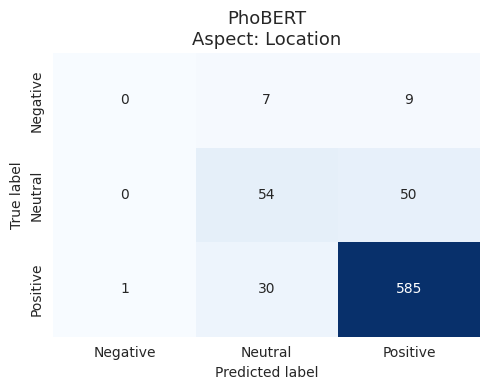


Plotting: Service
[[131   0  23]
 [  0   0   0]
 [ 17   0 618]]


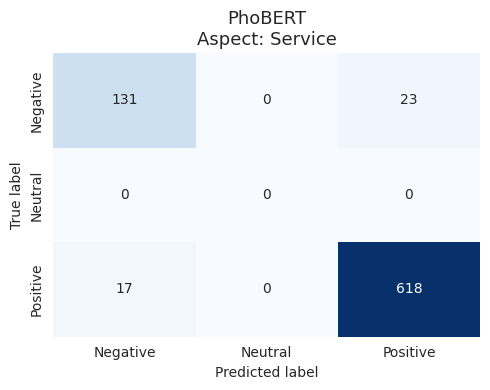


Plotting: Price
[[ 43   7   8]
 [ 15  24  31]
 [  5  22 159]]


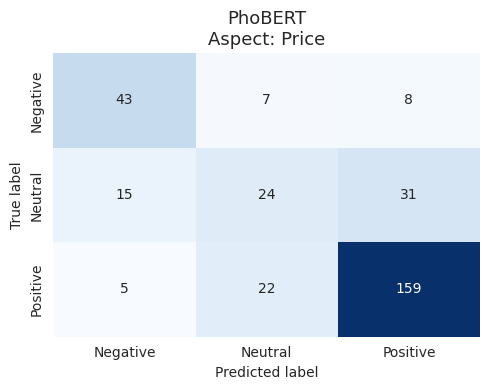


Plotting: Facilities
[[207  20  38]
 [ 42  34  55]
 [ 51  28 338]]


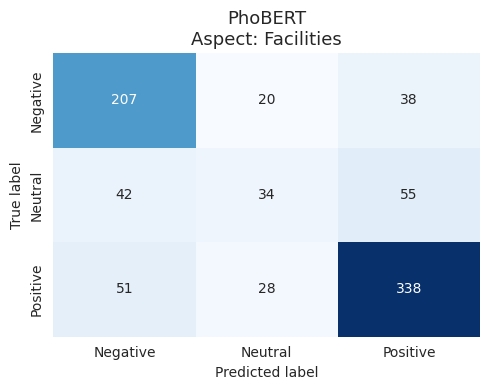


Plotting: Hygiene
[[ 57  20  11]
 [ 15 189  24]
 [  6  20 384]]


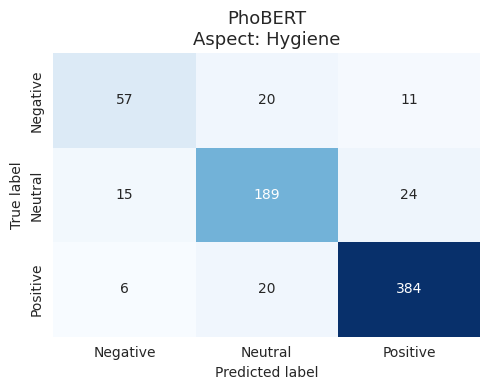

In [67]:
# A. PhoBERT
plot_confusion_matrix_absa(
    y_true_pb,
    y_pred_pb,
    "PhoBERT"
)

CONFUSION MATRIX - PhoBERT + BiLSTM

Plotting: Location
[[  1   4  10]
 [  1  56  46]
 [  1  38 573]]


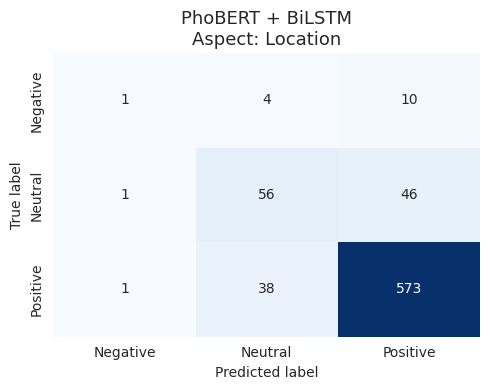


Plotting: Service
[[131   0  19]
 [  0   0   0]
 [ 26   0 613]]


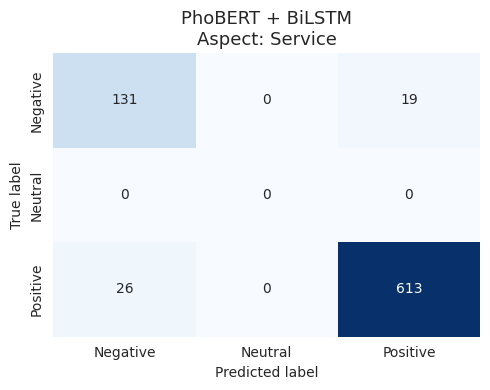


Plotting: Price
[[ 45   7   6]
 [ 10  25  31]
 [  7  21 161]]


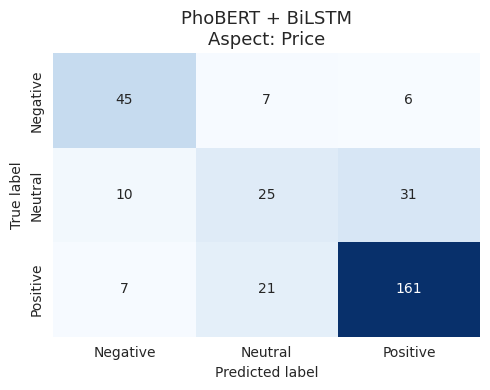


Plotting: Facilities
[[224  21  20]
 [ 46  50  38]
 [ 64  30 332]]


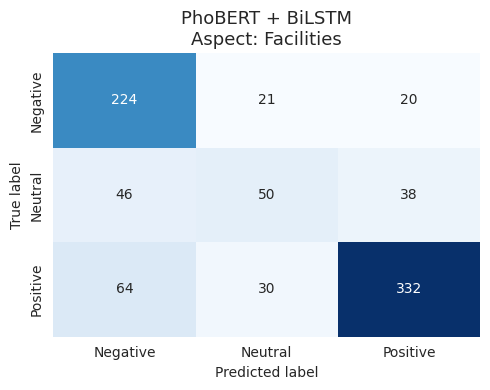


Plotting: Hygiene
[[ 63  16   9]
 [ 17 182  27]
 [ 12  16 373]]


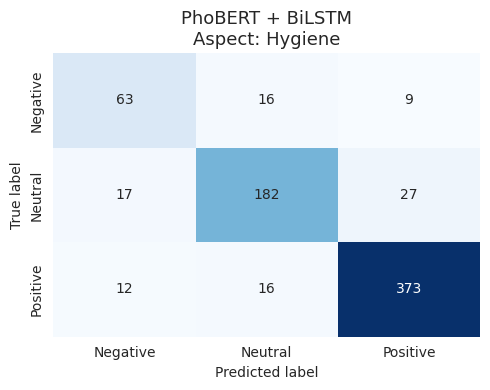

In [68]:
# B. PhoBERT + BiLSTM
plot_confusion_matrix_absa(
    y_true_h,
    y_pred_h,
    "PhoBERT + BiLSTM"
)

CONFUSION MATRIX - PhoBERT + BiLSTM + Augmentation

Plotting: Location
[[  0   6   9]
 [  0  60  48]
 [  1  40 577]]


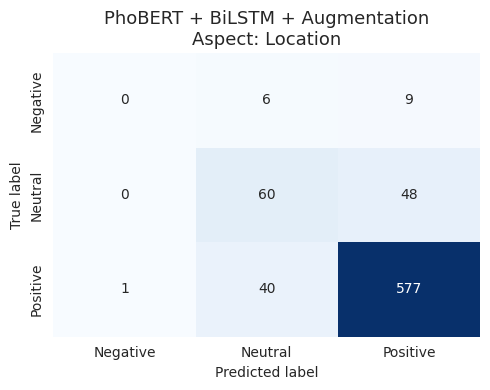


Plotting: Service
[[114   0  22]
 [  0   0   0]
 [ 18   0 615]]


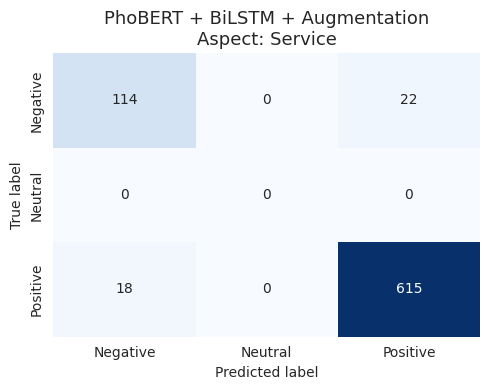


Plotting: Price
[[ 29   8  22]
 [  6  42  38]
 [  5  18 173]]


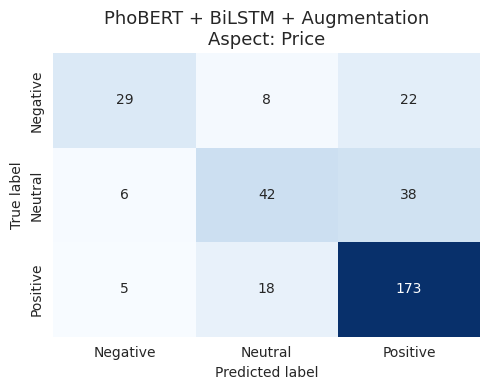


Plotting: Facilities
[[198  32  34]
 [ 36  76  26]
 [ 37  44 344]]


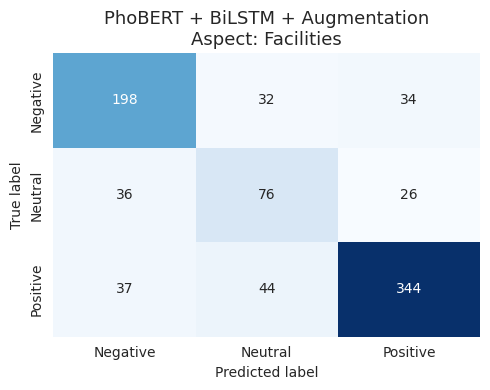


Plotting: Hygiene
[[ 53  21  16]
 [ 11 178  33]
 [  3  10 390]]


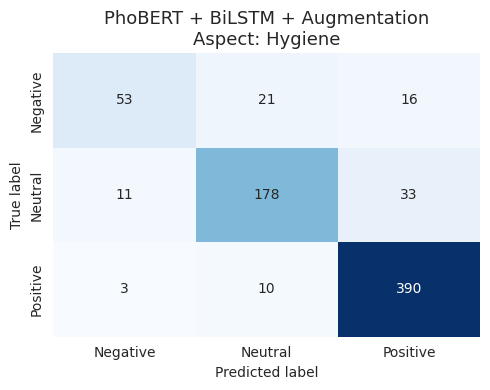

In [69]:
# C. Hybrid + Augmentation
plot_confusion_matrix_absa(
    y_true_ha,
    y_pred_ha,
    "PhoBERT + BiLSTM + Augmentation"
)

ERROR ANALYSIS

In [72]:
# 11. ERROR ANALYSIS
# =============================================================================
import pandas as pd
import numpy as np
from IPython.display import display

# Label mapping
LABEL_NAMES = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

# 1. Lấy các mẫu dự đoán sai theo từng aspect
def get_error_examples(
    y_true,
    y_pred,
    indices,
    val_df,
    aspect_name,
    n=5
):
    aspect_idx = ASPECTS.index(aspect_name)
    error_mask = (
        (y_true[:, aspect_idx] != y_pred[:, aspect_idx])
        &
        (y_true[:, aspect_idx] != NONE_VALUE)
    )

    error_positions = np.where(error_mask)[0]
    if len(error_positions) == 0:
        return pd.DataFrame()

    # lấy n ví dụ đầu tiên
    selected = error_positions[:n]

    # lấy review gốc trong validation set
    original_positions = indices[selected]


    result = val_df.iloc[
        original_positions
    ][
        ["Review_Final"]
    ].copy()

    result["Aspect"] = aspect_name
    result["Actual"] = [
        TARGET_NAMES[x] # Changed from LABEL_NAMES[x] to TARGET_NAMES[x]
        for x in y_true[selected, aspect_idx]
    ]

    result["Prediction"] = [
        TARGET_NAMES[x] # Changed from LABEL_NAMES[x] to TARGET_NAMES[x]
        for x in y_pred[selected, aspect_idx]
    ]

    result["Error_Type"] = (
        result["Actual"]
        +
        " → "
        +
        result["Prediction"]
    )
    return result.reset_index(drop=True)

# 2. Error Analysis cho toàn bộ aspect của 1 model
def error_analysis_all_aspects(
    y_true,
    y_pred,
    indices,
    val_df,
    model_name,
    n=5
):

    print("="*80)
    print(f"ERROR ANALYSIS: {model_name}")
    print("="*80)

    all_errors = []

    for aspect in ASPECTS:
        df_error = get_error_examples(
            y_true,
            y_pred,
            indices,
            val_df,
            aspect,
            n
        )

        if len(df_error) > 0:
            all_errors.append(df_error)

    if len(all_errors) == 0:
        print("Không tìm thấy lỗi.")
        return pd.DataFrame()
    error_df = pd.concat(
        all_errors,
        ignore_index=True
    )
    print(
        f"Tổng số ví dụ lỗi được trích xuất: {len(error_df)}"
    )
    display(error_df)
    return error_df

# 3. Thống kê phân bố lỗi
def error_distribution(error_df, model_name):
    print("="*80)
    print(f"ERROR DISTRIBUTION: {model_name}")
    print("="*80)

    if len(error_df)==0:
        print("Không có dữ liệu.")
        return

    print("\n1. Errors by Aspect")

    aspect_count = (
        error_df["Aspect"]
        .value_counts()
    )
    display(
        aspect_count.to_frame("Number_of_errors"))

    print("\n2. Error Type Distribution")
    error_type = (
        error_df["Error_Type"]
        .value_counts()
    )
    display(
        error_type.to_frame("Count"))

# 4. Chạy cho 3 mô hình
# PhoBERT
error_pb = error_analysis_all_aspects(
    y_true_pb,
    y_pred_pb,
    idx_pb,
    val_pb,
    "PhoBERT",n=5)

# PhoBERT + BiLSTM
error_h = error_analysis_all_aspects(
    y_true_h,
    y_pred_h,
    idx_h,
    val_h,
    "PhoBERT + BiLSTM",n=5)

# Hybrid + Augmentation
error_ha = error_analysis_all_aspects(
    y_true_ha,
    y_pred_ha,
    idx_ha,
    val_h, # Changed val_ha to val_h
    "PhoBERT + BiLSTM + Augmentation",n=5)

ERROR ANALYSIS: PhoBERT
Tổng số ví dụ lỗi được trích xuất: 25


,Review_Final,Aspect,Actual,Prediction,Error_Type
0,phòng nhưng tiện_nghi nhân_viên lịch_thiệp,Vị trí,Tích cực,Trung lập,Tích cực → Trung lập
1,sạch_sẽ đẹp khách_sạn tuyệt_vời tối nhà_hàng n...,Vị trí,Trung lập,Tích cực,Trung lập → Tích cực
2,hy_vọng dịch được phòng_ốc sạch_sẽ hài_lòng gi...,Vị trí,Tích cực,None,Tích cực → None
3,khách_sạn nằm đường 1 chiều hơi bất_tiện đi_lại,Vị trí,Tiêu cực,Tích cực,Tiêu cực → Tích cực
4,nhân_viên thân_thiện nhanh_nhẹn phòng rộng_rãi...,Vị trí,Trung lập,Tích cực,Trung lập → Tích cực
5,phòng rộng sạch,Dịch vụ,Tích cực,None,Tích cực → None
6,nhân_viên niềm_nở dễ_thương tuy_nhiên chưa xứn...,Dịch vụ,Tiêu cực,Tích cực,Tiêu cực → Tích cực
7,tạm ổn 2 đêm ban_đầu khách_sạn phòng siêu tệ m...,Dịch vụ,Tích cực,None,Tích cực → None
8,phòng tuyệt_vời vị_trí đẹp chất_lượng vị_trí n...,Dịch vụ,Tiêu cực,Tích cực,Tiêu cực → Tích cực
9,chúng_tôi nửa_đêm bắt chuyến bay nhưng nhân_vi...,Dịch vụ,Tích cực,Tiêu cực,Tích cực → Tiêu cực


ERROR ANALYSIS: PhoBERT + BiLSTM
Tổng số ví dụ lỗi được trích xuất: 25


,Review_Final,Aspect,Actual,Prediction,Error_Type
0,phòng nhưng tiện_nghi nhân_viên lịch_thiệp,Vị trí,Tích cực,Trung lập,Tích cực → Trung lập
1,sạch_sẽ đẹp khách_sạn tuyệt_vời tối nhà_hàng n...,Vị trí,Trung lập,Tích cực,Trung lập → Tích cực
2,hy_vọng dịch được phòng_ốc sạch_sẽ hài_lòng gi...,Vị trí,Tích cực,None,Tích cực → None
3,tuyệt_vời,Vị trí,Tích cực,None,Tích cực → None
4,khách_sạn nằm đường 1 chiều hơi bất_tiện đi_lại,Vị trí,Tiêu cực,Tích cực,Tiêu cực → Tích cực
5,phòng rộng sạch,Dịch vụ,Tích cực,None,Tích cực → None
6,khách_sạn cổ_điển khu_vực thành_phố hồ chí min...,Dịch vụ,Tích cực,Tiêu cực,Tích cực → Tiêu cực
7,cơ_sở vật_chất phòng không xứng_đáng tiền phòn...,Dịch vụ,Tiêu cực,None,Tiêu cực → None
8,khách_sạn sạch_sẽ vị_trí trung_tâm nhân_viên c...,Dịch vụ,Tích cực,None,Tích cực → None
9,tạm ổn 2 đêm ban_đầu khách_sạn phòng siêu tệ m...,Dịch vụ,Tích cực,None,Tích cực → None


ERROR ANALYSIS: PhoBERT + BiLSTM + Augmentation
Tổng số ví dụ lỗi được trích xuất: 25


,Review_Final,Aspect,Actual,Prediction,Error_Type
0,phòng nhưng tiện_nghi nhân_viên lịch_thiệp,Vị trí,Tích cực,Trung lập,Tích cực → Trung lập
1,sạch_sẽ đẹp khách_sạn tuyệt_vời tối nhà_hàng n...,Vị trí,Trung lập,Tích cực,Trung lập → Tích cực
2,hy_vọng dịch được phòng_ốc sạch_sẽ hài_lòng gi...,Vị trí,Tích cực,None,Tích cực → None
3,tuyệt_vời,Vị trí,Tích cực,None,Tích cực → None
4,khách_sạn nằm đường 1 chiều hơi bất_tiện đi_lại,Vị trí,Tiêu cực,Tích cực,Tiêu cực → Tích cực
5,phòng rộng sạch,Dịch vụ,Tích cực,None,Tích cực → None
6,vị_trí dịch_vụ khách_sạn nhưng trái_tim nhân_v...,Dịch vụ,Tích cực,None,Tích cực → None
7,hy_vọng dịch được phòng_ốc sạch_sẽ hài_lòng gi...,Dịch vụ,Tích cực,None,Tích cực → None
8,cơ_sở vật_chất phòng không xứng_đáng tiền phòn...,Dịch vụ,Tiêu cực,None,Tiêu cực → None
9,khách_sạn training nhân_viên dịch_vụ trở_nên n...,Dịch vụ,Tích cực,Tiêu cực,Tích cực → Tiêu cực


In [73]:
error_distribution(
    error_pb,
    "PhoBERT"
)


error_distribution(
    error_h,
    "PhoBERT + BiLSTM"
)


error_distribution(
    error_ha,
    "PhoBERT + BiLSTM + Augmentation"
)

ERROR DISTRIBUTION: PhoBERT

1. Errors by Aspect


,Number_of_errors
Aspect,
Vị trí,5
Dịch vụ,5
Giá cả,5
Cơ sở vật chất,5
Vệ sinh,5



2. Error Type Distribution


,Count
Error_Type,
Tiêu cực → Tích cực,7
Tích cực → None,5
Trung lập → Tích cực,4
Trung lập → None,3
Tích cực → Trung lập,2
Tích cực → Tiêu cực,2
Trung lập → Tiêu cực,2


ERROR DISTRIBUTION: PhoBERT + BiLSTM

1. Errors by Aspect


...

,Count
Error_Type,
Tích cực → None,9
Trung lập → None,4
Tiêu cực → Tích cực,3
Trung lập → Tích cực,3
Trung lập → Tiêu cực,2
Tích cực → Tiêu cực,2
Tích cực → Trung lập,1
Tiêu cực → None,1


ERROR DISTRIBUTION: PhoBERT + BiLSTM + Augmentation

1. Errors by Aspect


,Number_of_errors
Aspect,
Vị trí,5
Dịch vụ,5
Giá cả,5
Cơ sở vật chất,5
Vệ sinh,5



2. Error Type Distribution


,Count
Error_Type,
Tích cực → None,8
Tích cực → Trung lập,3
Trung lập → Tích cực,3
Tiêu cực → Tích cực,3
Tiêu cực → None,2
Tích cực → Tiêu cực,2
Trung lập → Tiêu cực,2
Trung lập → None,2
